Will eventually add things here (have added things here)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from knnbench.datasets import load_breast_cancer_df, load_adult_df, preprocess_adult_df, transform_adult_df
from knnbench.utils import compute_metrics, set_seed

from experiments.manual_knn import ManualKNNClassifier

Below is test on the breast cancer dataset

In [2]:
set_seed()

X, y = load_breast_cancer_df()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("\nManual KNN with uniform voting:")
knn = ManualKNNClassifier(k=5, voting="uniform").fit(X_train_s, y_train)

y_pred = knn.predict(X_test_s)

metrics = compute_metrics(y_test, y_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

print("\nManual KNN with distance voting:")
knn = ManualKNNClassifier(k=5, voting="distance").fit(X_train_s, y_train)

y_pred = knn.predict(X_test_s)

metrics = compute_metrics(y_test, y_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")


Manual KNN with uniform voting:
accuracy: 0.9123
macro_recall: 0.9206
macro_f1: 0.9082
precision_0: 0.8333
recall_0: 0.9524
f1_0: 0.8889
precision_1: 0.9697
recall_1: 0.8889
f1_1: 0.9275

Manual KNN with distance voting:
accuracy: 0.9211
macro_recall: 0.9226
macro_f1: 0.9164
precision_0: 0.8667
recall_0: 0.9286
f1_0: 0.8966
precision_1: 0.9565
recall_1: 0.9167
f1_1: 0.9362


Below is test on the adult set


Manual KNN with uniform voting:
accuracy: 0.8437
macro_recall: 0.7633
macro_f1: 0.7751
precision_<=50K: 0.8818
recall_<=50K: 0.9175
f1_<=50K: 0.8993
precision_>50K: 0.6991
recall_>50K: 0.6091
f1_>50K: 0.6510


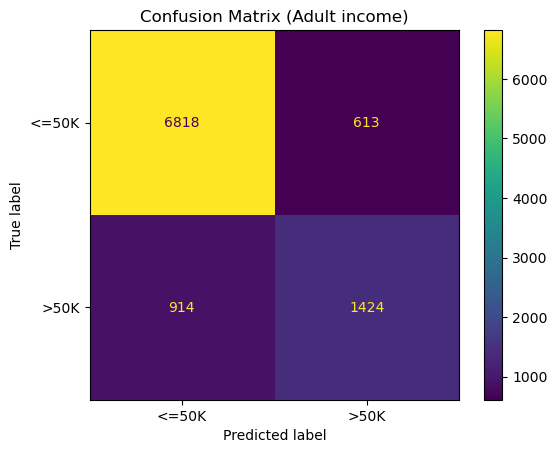


Manual KNN with distance voting:
accuracy: 0.8383
macro_recall: 0.7580
macro_f1: 0.7684
precision_<=50K: 0.8798
recall_<=50K: 0.9120
f1_<=50K: 0.8956
precision_>50K: 0.6834
recall_>50K: 0.6039
f1_>50K: 0.6412


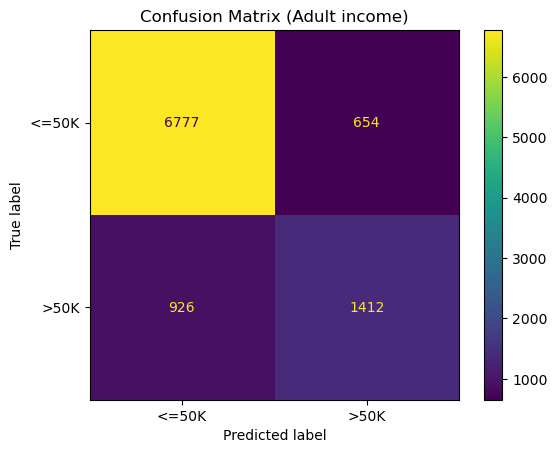

In [4]:
seed = 42
set_seed(seed)

k = 9
alpha = 0
scaling = "standard"

X, y = load_adult_df()

X.drop(columns=["fnlwgt"], inplace=True)  # Drop 'fnlwgt' as it's not a feature

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

X_train_proc, prep = preprocess_adult_df(X_train, scaling=scaling, return_preprocessor=True)
X_test_proc = transform_adult_df(X_test, prep)

print("\nManual KNN with uniform voting:")
knn = ManualKNNClassifier(k=k, voting="uniform", alpha=alpha).fit(X_train_proc, y_train)

y_pred = knn.predict(X_test_proc)

metrics = compute_metrics(y_test, y_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

labels = ["<=50K", ">50K"] 
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Adult income)")
plt.show()

print("\nManual KNN with distance voting:")
knn = ManualKNNClassifier(k=k, voting="distance", alpha=alpha).fit(X_train_proc, y_train)

y_pred = knn.predict(X_test_proc, 512)

metrics = compute_metrics(y_test, y_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

labels = ["<=50K", ">50K"] 
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Adult income)")
plt.show()